In [2]:
# importing needed packages
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt

In [3]:

#read in Central Valley csvs from external drive
#path1 = '/Volumes/disk1/Central Valley Fog/4205333.csv'
#path2 = '/Volumes/disk1/Central Valley Fog/4206426.csv'
#path3 = '/Volumes/disk1/Central Valley Fog/4206427.csv'
path1 = 'E:/Central Valley Fog/4205333.csv'
path2 = 'E:/Central Valley Fog/4206426.csv'
path3 = 'E:/Central Valley Fog/4206427.csv'


#df1 = pd.read_csv(path1, usecols=['STATION', 'DATE', 'HourlyPrecipitation', 'HourlyRelativeHumidity', 'HourlyVisibility'])
#df2 = pd.read_csv(path2, usecols=['STATION', 'DATE', 'HourlyPrecipitation', 'HourlyRelativeHumidity', 'HourlyVisibility'])
#df3 = pd.read_csv(path3, usecols=['STATION', 'DATE', 'HourlyPrecipitation', 'HourlyRelativeHumidity', 'HourlyVisibility'])

#df1 = pd.read_csv(path1, usecols=[0, 5, 42, 46, 50])
#df2 = pd.read_csv(path2, usecols=[0, 5, 42, 46, 50])  
#df3 = pd.read_csv(path3, usecols=[0, 5, 42, 46, 50])

In [4]:
# create dataframes with only the columns we need
# units: HourlyVisibility: km to thousandths, HourlyPrecipitation: mm to tenths
df1 = pd.read_csv(path1, usecols=['STATION', 'DATE', 'LATITUDE', 'LONGITUDE', 'HourlyVisibility','HourlyPrecipitation'],low_memory=False)
df2 = pd.read_csv(path2, usecols=['STATION', 'DATE', 'LATITUDE', 'LONGITUDE', 'HourlyVisibility','HourlyPrecipitation'],low_memory=False)
df3 = pd.read_csv(path3, usecols=['STATION', 'DATE', 'LATITUDE', 'LONGITUDE', 'HourlyVisibility','HourlyPrecipitation'],low_memory=False)


In [5]:
df1.head()

,STATION,LATITUDE,LONGITUDE,DATE,HourlyPrecipitation,HourlyVisibility
0,USW00093210,39.49,-121.61833,1998-06-13T00:00:00,NaN,NaN
1,USW00093210,39.49,-121.61833,1998-06-15T00:00:00,NaN,NaN
2,USW00093210,39.49,-121.61833,1998-06-16T00:00:00,NaN,NaN
3,USW00093210,39.49,-121.61833,1998-06-17T00:00:00,NaN,NaN
4,USW00093210,39.49,-121.61833,1998-06-18T00:00:00,NaN,NaN


In [6]:
# print all column names
for col in df1.columns:
    print(col)

STATION
LATITUDE
LONGITUDE
DATE
HourlyPrecipitation
HourlyVisibility


In [7]:
# create dataframes with monthy number days w heavy fog
# monthly number days with heavy fog: number of days in month with visibility less than 1/4 statute mile
df1fog = pd.read_csv(path1, usecols=['STATION', 'DATE', 'LATITUDE', 'LONGITUDE', 'MonthlyNumberDaysWithHeavyFog'],low_memory=False)
df2fog = pd.read_csv(path2, usecols=['STATION', 'DATE', 'LATITUDE', 'LONGITUDE', 'MonthlyNumberDaysWithHeavyFog'],low_memory=False)
df3fog = pd.read_csv(path3, usecols=['STATION', 'DATE', 'LATITUDE', 'LONGITUDE', 'MonthlyNumberDaysWithHeavyFog'],low_memory=False)

dffog_list = [df1fog, df2fog, df3fog]
fogdays_data = pd.concat(dffog_list, ignore_index=True)

print(fogdays_data.head())

       STATION  LATITUDE  LONGITUDE                 DATE  \
0  USW00093210     39.49 -121.61833  1998-06-13T00:00:00   
1  USW00093210     39.49 -121.61833  1998-06-15T00:00:00   
2  USW00093210     39.49 -121.61833  1998-06-16T00:00:00   
3  USW00093210     39.49 -121.61833  1998-06-17T00:00:00   
4  USW00093210     39.49 -121.61833  1998-06-18T00:00:00   

   MonthlyNumberDaysWithHeavyFog  
0                            NaN  
1                            NaN  
2                            NaN  
3                            NaN  
4                            NaN  


In [8]:
df_list = [df1, df2, df3] 

CV_data = pd.concat(df_list, ignore_index = True)

print(CV_data.head(5))

       STATION  LATITUDE  LONGITUDE                 DATE HourlyPrecipitation  \
0  USW00093210     39.49 -121.61833  1998-06-13T00:00:00                 NaN   
1  USW00093210     39.49 -121.61833  1998-06-15T00:00:00                 NaN   
2  USW00093210     39.49 -121.61833  1998-06-16T00:00:00                 NaN   
3  USW00093210     39.49 -121.61833  1998-06-17T00:00:00                 NaN   
4  USW00093210     39.49 -121.61833  1998-06-18T00:00:00                 NaN   

  HourlyVisibility  
0              NaN  
1              NaN  
2              NaN  
3              NaN  
4              NaN  


In [9]:
# select rows where all columns are not null
CV_rows = CV_data[CV_data.notna().all(axis=1)]
print(CV_rows)

              STATION  LATITUDE  LONGITUDE                 DATE  \
53944     USW00093210  39.49000 -121.61833  2004-12-31T16:53:00   
53945     USW00093210  39.49000 -121.61833  2004-12-31T17:38:00   
53946     USW00093210  39.49000 -121.61833  2004-12-31T17:53:00   
53947     USW00093210  39.49000 -121.61833  2004-12-31T18:26:00   
53948     USW00093210  39.49000 -121.61833  2004-12-31T18:44:00   
...               ...       ...        ...                  ...   
16275879  USW00023167  36.73333 -119.81667  2025-12-26T02:55:00   
16275882  USW00023167  36.73333 -119.81667  2025-12-26T03:55:00   
16275885  USW00023167  36.73333 -119.81667  2025-12-26T04:55:00   
16275888  USW00023167  36.73333 -119.81667  2025-12-26T05:55:00   
16276267  USW00023167  36.73333 -119.81667  2025-12-31T15:55:00   

         HourlyPrecipitation HourlyVisibility  
53944                    1.5           16.093  
53945                    0.3           16.093  
53946                    0.3           16.093  
539

In [10]:
fogdays_rows = fogdays_data[fogdays_data.notna().all(axis=1)]

print(fogdays_rows.head())

           STATION  LATITUDE  LONGITUDE                 DATE  \
65575  USW00093210     39.49 -121.61833  2006-01-31T23:59:00   
66443  USW00093210     39.49 -121.61833  2006-02-28T23:59:00   
68370  USW00093210     39.49 -121.61833  2006-04-30T23:59:00   
74102  USW00093210     39.49 -121.61833  2006-11-30T23:59:00   
75138  USW00093210     39.49 -121.61833  2006-12-31T23:59:00   

       MonthlyNumberDaysWithHeavyFog  
65575                            4.0  
66443                            1.0  
68370                            1.0  
74102                            5.0  
75138                            2.0  


In [76]:
# convert date column to datetime format
CV_rows["DATE"] = pd.to_datetime(CV_rows["DATE"])
fogdays_rows["DATE"] = pd.to_datetime(fogdays_rows["DATE"])

In [77]:
# extract year and month from date column and add as new columns
CV_rows["year"] = CV_rows["DATE"].dt.year
CV_rows["month"] = CV_rows["DATE"].dt.month
CV_rows["day"] = CV_rows["DATE"].dt.day
CV_rows["hour"] = CV_rows["DATE"].dt.hour
CV_rows["minute"] = CV_rows["DATE"].dt.minute
print(CV_rows.head(5))

           STATION  LATITUDE  LONGITUDE                DATE  \
53944  USW00093210     39.49 -121.61833 2004-12-31 16:53:00   
53945  USW00093210     39.49 -121.61833 2004-12-31 17:38:00   
53946  USW00093210     39.49 -121.61833 2004-12-31 17:53:00   
53947  USW00093210     39.49 -121.61833 2004-12-31 18:26:00   
53948  USW00093210     39.49 -121.61833 2004-12-31 18:44:00   

      HourlyPrecipitation HourlyVisibility  year  month  day  hour  minute  
53944                 1.5           16.093  2004     12   31    16      53  
53945                 0.3           16.093  2004     12   31    17      38  
53946                 0.3           16.093  2004     12   31    17      53  
53947                 0.5            9.656  2004     12   31    18      26  
53948                 2.0            8.047  2004     12   31    18      44  


In [78]:
# convert hourly precipitation and visibility to numeric values
CV_rows["HourlyPrecipitation"] = pd.to_numeric(CV_rows["HourlyPrecipitation"], errors='coerce')
CV_rows["HourlyVisibility"] = pd.to_numeric(CV_rows["HourlyVisibility"], errors='coerce')

In [79]:
# make dataframe with only columns where precipitation is less than 0.03mm
CV_precip_rows = CV_rows[CV_rows['HourlyPrecipitation'] < 0.03]

In [80]:
CV_precip_rows.head()

,STATION,LATITUDE,LONGITUDE,DATE,HourlyPrecipitation,HourlyVisibility,year,month,day,hour,minute
53956,USW00093210,39.49,-121.61833,2004-12-31 22:53:00,0.0,16.093,2004,12,31,22,53
53963,USW00093210,39.49,-121.61833,2005-01-01 00:53:00,0.0,16.093,2005,1,1,0,53
53965,USW00093210,39.49,-121.61833,2005-01-01 01:53:00,0.0,16.093,2005,1,1,1,53
53966,USW00093210,39.49,-121.61833,2005-01-01 02:53:00,0.0,16.093,2005,1,1,2,53
53967,USW00093210,39.49,-121.61833,2005-01-01 03:53:00,0.0,16.093,2005,1,1,3,53


In [81]:
# make dataframe with only columns where visibility is less than 1 km
CV_fog_rows = CV_rows[CV_rows['HourlyVisibility'] < 1.0]

In [82]:
# dataframe with only columns where visibility is less than 0.4 km
CV_densefog_rows = CV_rows[CV_rows['HourlyVisibility'] < 0.4]

In [83]:
# fill NaN precip values with 0
CV_fog_rows['HourlyPrecipitation'] = CV_fog_rows['HourlyPrecipitation'].fillna(0)
CV_densefog_rows['HourlyPrecipitation'] = CV_densefog_rows['HourlyPrecipitation'].fillna(0)
print(CV_fog_rows)

              STATION  LATITUDE  LONGITUDE                DATE  \
54139     USW00093210  39.49000 -121.61833 2005-01-06 03:53:00   
54140     USW00093210  39.49000 -121.61833 2005-01-06 04:53:00   
54142     USW00093210  39.49000 -121.61833 2005-01-06 05:53:00   
54143     USW00093210  39.49000 -121.61833 2005-01-06 06:53:00   
54144     USW00093210  39.49000 -121.61833 2005-01-06 07:53:00   
...               ...       ...        ...                 ...   
15979491  USW00093216  39.13333 -121.43333 2025-12-31 03:55:00   
15979495  USW00093216  39.13333 -121.43333 2025-12-31 04:55:00   
15979499  USW00093216  39.13333 -121.43333 2025-12-31 06:55:00   
16243343  USW00023167  36.73333 -119.81667 2023-12-22 05:55:00   
16271421  USW00023167  36.73333 -119.81667 2025-10-23 07:55:00   

          HourlyPrecipitation  HourlyVisibility  year  month  day  hour  \
54139                     0.0             0.402  2005      1    6     3   
54140                     0.0             0.402  2005    

In [84]:
fog_days_by_month = (
    CV_fog_rows
    .assign(fog_date=CV_fog_rows["DATE"].dt.date)
    .drop_duplicates(subset=["STATION", "year", "month", "fog_date"])
    .groupby(["STATION", "year", "month"], as_index=False)
    .size()
    .rename(columns={"size": "fog_days"})
)

print(fog_days_by_month.head())

       STATION  year  month  fog_days
0  USW00000479  2014     11         1
1  USW00000479  2014     12         3
2  USW00000479  2015      7         1
3  USW00000479  2015     11         2
4  USW00000479  2015     12         6


In [85]:
densefog_days_by_month = (
    CV_densefog_rows
    .assign(fog_date=CV_densefog_rows["DATE"].dt.date)
    .drop_duplicates(subset=["STATION", "year", "month", "fog_date"])
    .groupby(["STATION", "year", "month"], as_index=False)
    .size()
    .rename(columns={"size": "fog_days"})
)

print(densefog_days_by_month.head())

       STATION  year  month  fog_days
0  USW00000479  2014     11         1
1  USW00000479  2014     12         1
2  USW00000479  2015     11         1
3  USW00000479  2015     12         2
4  USW00000479  2016      1         1


       STATION  year  densefog_days  reported_heavy_fog_days  difference
0  USW00000479  2014            2.0                      0.0         2.0
1  USW00000479  2015            3.0                      0.0         3.0
2  USW00000479  2016            4.0                      0.0         4.0
3  USW00000479  2017            4.0                      0.0         4.0
4  USW00000479  2018            5.0                      0.0         5.0
Total rows: 671
Mismatches (difference != 0): 662
Top 10 absolute differences:
         STATION  year  densefog_days  reported_heavy_fog_days  difference  \
332  USW00023237  1972            0.0                     61.0       -61.0   
53   USW00023110  1968            0.0                     60.0       -60.0   
531  USW00093193  1962           56.0                      0.0        56.0   
532  USW00093193  1963           55.0                      0.0        55.0   
328  USW00023237  1968            0.0                     55.0       -55.0   
257  USW0002323

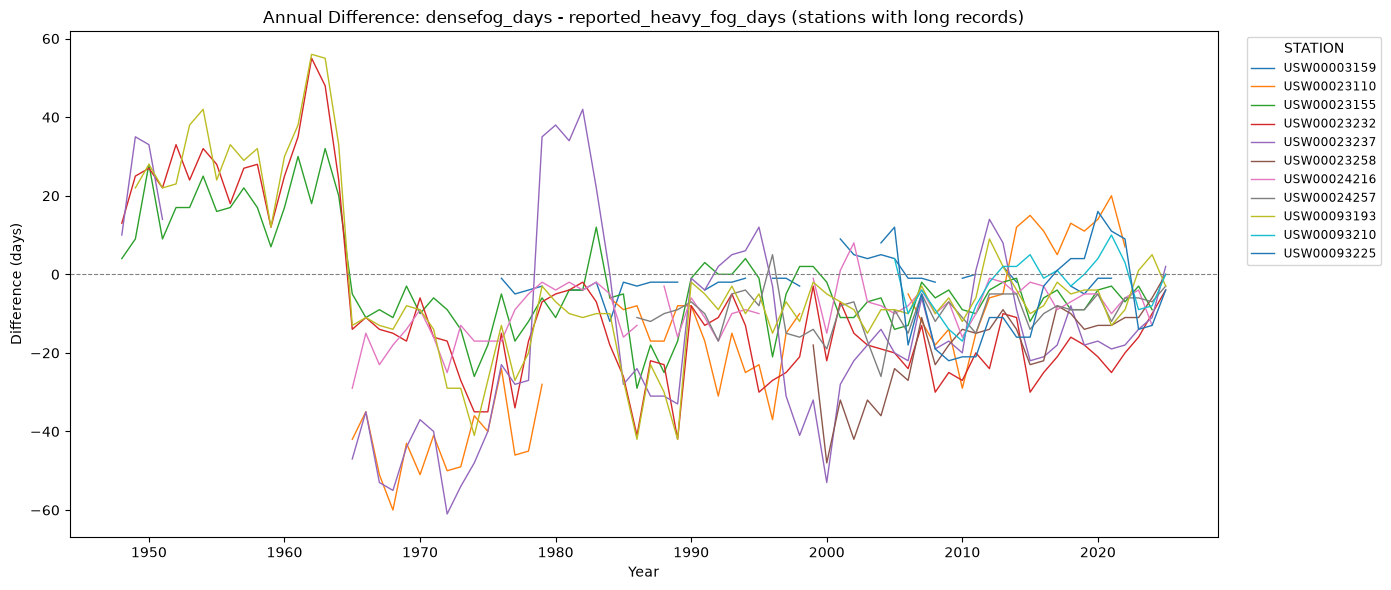

In [89]:
# annual totals and comparison for dense fog vs reported heavy fog
dense_annual = densefog_monthly.groupby(['STATION','year'], as_index=False)['densefog_days'].sum()
heavy_annual = heavyfog_monthly.groupby(['STATION','year'], as_index=False)['reported_heavy_fog_days'].sum()

annual_comp = pd.merge(dense_annual, heavy_annual, on=['STATION','year'], how='outer').fillna(0)
annual_comp['difference'] = annual_comp['densefog_days'] - annual_comp['reported_heavy_fog_days']

print(annual_comp.head())
print("Total rows:", len(annual_comp))
print("Mismatches (difference != 0):", len(annual_comp[annual_comp['difference'] != 0]))
print("Top 10 absolute differences:")
print(annual_comp.assign(absdiff=annual_comp['difference'].abs()).sort_values('absdiff', ascending=False).head(10))

# plot differences per year for stations with long records
plot_df = annual_comp[annual_comp['STATION'].isin(stations_with_long_record)].pivot(index='year', columns='STATION', values='difference')
fig, ax = plt.subplots(figsize=(14,6))
plot_df.plot(ax=ax, linewidth=1)
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set_title('Annual Difference: densefog_days - reported_heavy_fog_days (stations with long records)')
ax.set_xlabel('Year')
ax.set_ylabel('Difference (days)')
ax.legend(title='STATION', bbox_to_anchor=(1.02,1), loc='upper left', fontsize='small')
plt.tight_layout()
plt.show()

In [87]:
# compare monthly fog days from hourly CV fog rows with monthly fog days recorded in fog days data

# monthly fog days from CV_fog_rows
cv_monthly_fogdays = (
    CV_fog_rows
    .assign(fog_date=CV_fog_rows["DATE"].dt.date)
    .drop_duplicates(subset=["STATION", "year", "month", "fog_date"])
    .groupby(["STATION", "year", "month"], as_index=False)
    .size()
    .rename(columns={"size": "CV_fog_days"})
)

# monthly fog days from fogdays_rows
fogdays_rows["MonthlyNumberDaysWithHeavyFog"] = pd.to_numeric(
    fogdays_rows["MonthlyNumberDaysWithHeavyFog"], errors="coerce"
)

fogdays_monthly = (
    fogdays_rows
    .assign(year=fogdays_rows["DATE"].dt.year, month=fogdays_rows["DATE"].dt.month)
    .groupby(["STATION", "year", "month"], as_index=False)["MonthlyNumberDaysWithHeavyFog"]
    .sum()
    .rename(columns={"MonthlyNumberDaysWithHeavyFog": "reported_fog_days"})
)

comparison = pd.merge(
    cv_monthly_fogdays,
    fogdays_monthly,
    on=["STATION", "year", "month"],
    how="outer"
).fillna(0)

comparison["difference"] = comparison["CV_fog_days"] - comparison["reported_fog_days"]
comparison = comparison.sort_values(["STATION", "year", "month"])

print(comparison.head(20))
print("Total comparisons:", len(comparison))
print("Mismatches:", len(comparison[comparison["difference"] != 0]))
print(comparison[comparison["difference"] != 0].head(20))

        STATION  year  month  CV_fog_days  reported_fog_days  difference
0   USW00000479  2014     11          1.0                0.0         1.0
1   USW00000479  2014     12          3.0                0.0         3.0
2   USW00000479  2015      7          1.0                0.0         1.0
3   USW00000479  2015     11          2.0                0.0         2.0
4   USW00000479  2015     12          6.0                0.0         6.0
5   USW00000479  2016      1          5.0                0.0         5.0
6   USW00000479  2016      2          1.0                0.0         1.0
7   USW00000479  2016      3          1.0                0.0         1.0
8   USW00000479  2016      5          1.0                0.0         1.0
9   USW00000479  2016     10          1.0                0.0         1.0
10  USW00000479  2016     11          3.0                0.0         3.0
11  USW00000479  2016     12          1.0                0.0         1.0
12  USW00000479  2017      1          6.0          

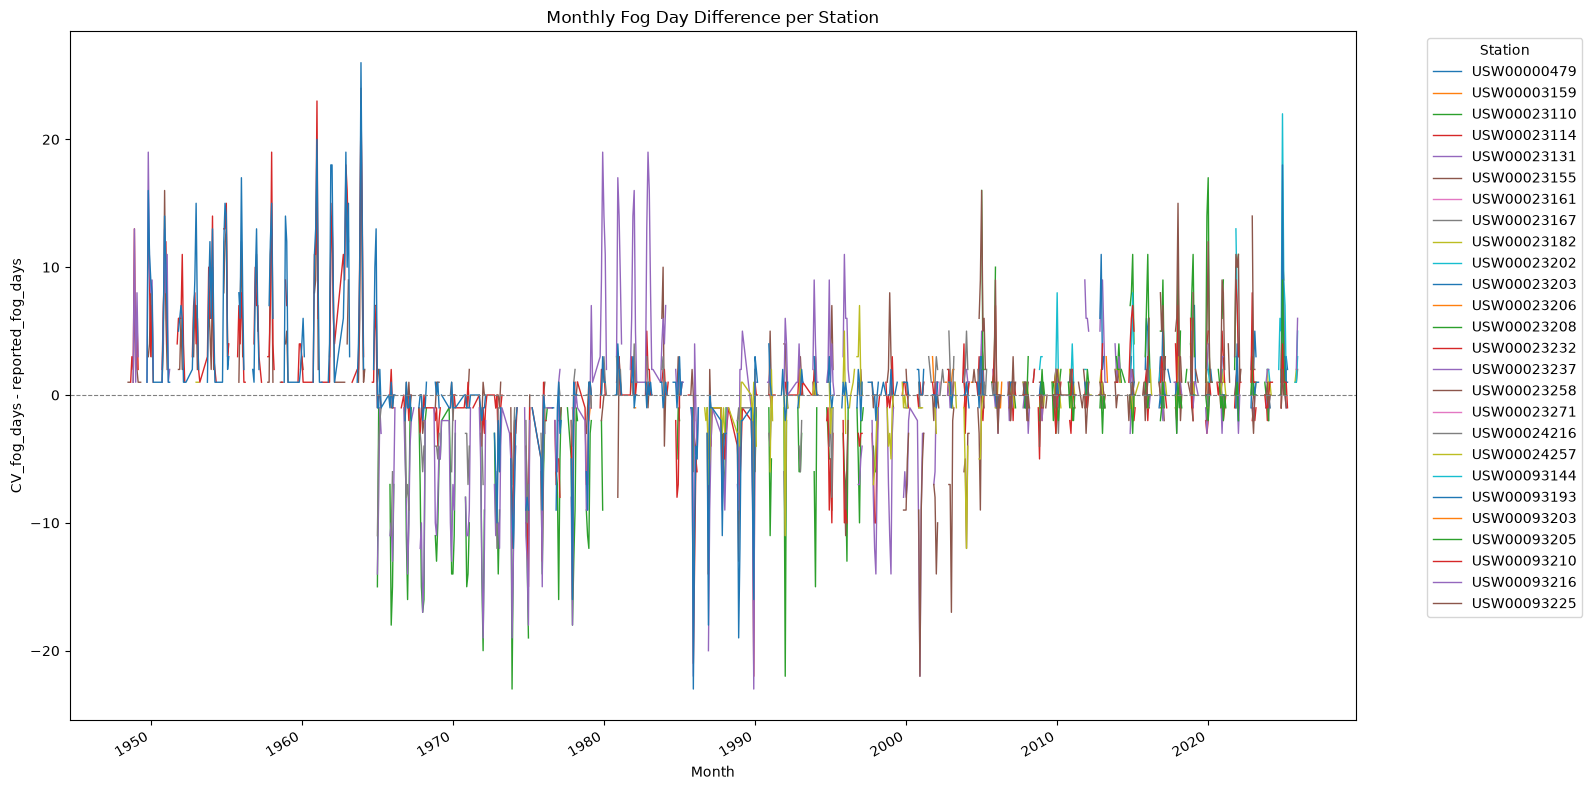

In [52]:
#compare the differences in fog days between the two datasets and plot them
comparison_plot = comparison.copy()
comparison_plot["period"] = pd.to_datetime(
    comparison_plot["year"].astype(str) + "-" +
    comparison_plot["month"].astype(str).str.zfill(2) + "-01"
)

diff_pivot = comparison_plot.pivot_table(
    index="period",
    columns="STATION",
    values="difference"
)

fig, ax = plt.subplots(figsize=(16, 8))
diff_pivot.plot(ax=ax, linewidth=1)
ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax.set_title("Monthly Fog Day Difference per Station")
ax.set_xlabel("Month")
ax.set_ylabel("CV_fog_days - reported_fog_days")
ax.legend(title="Station", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

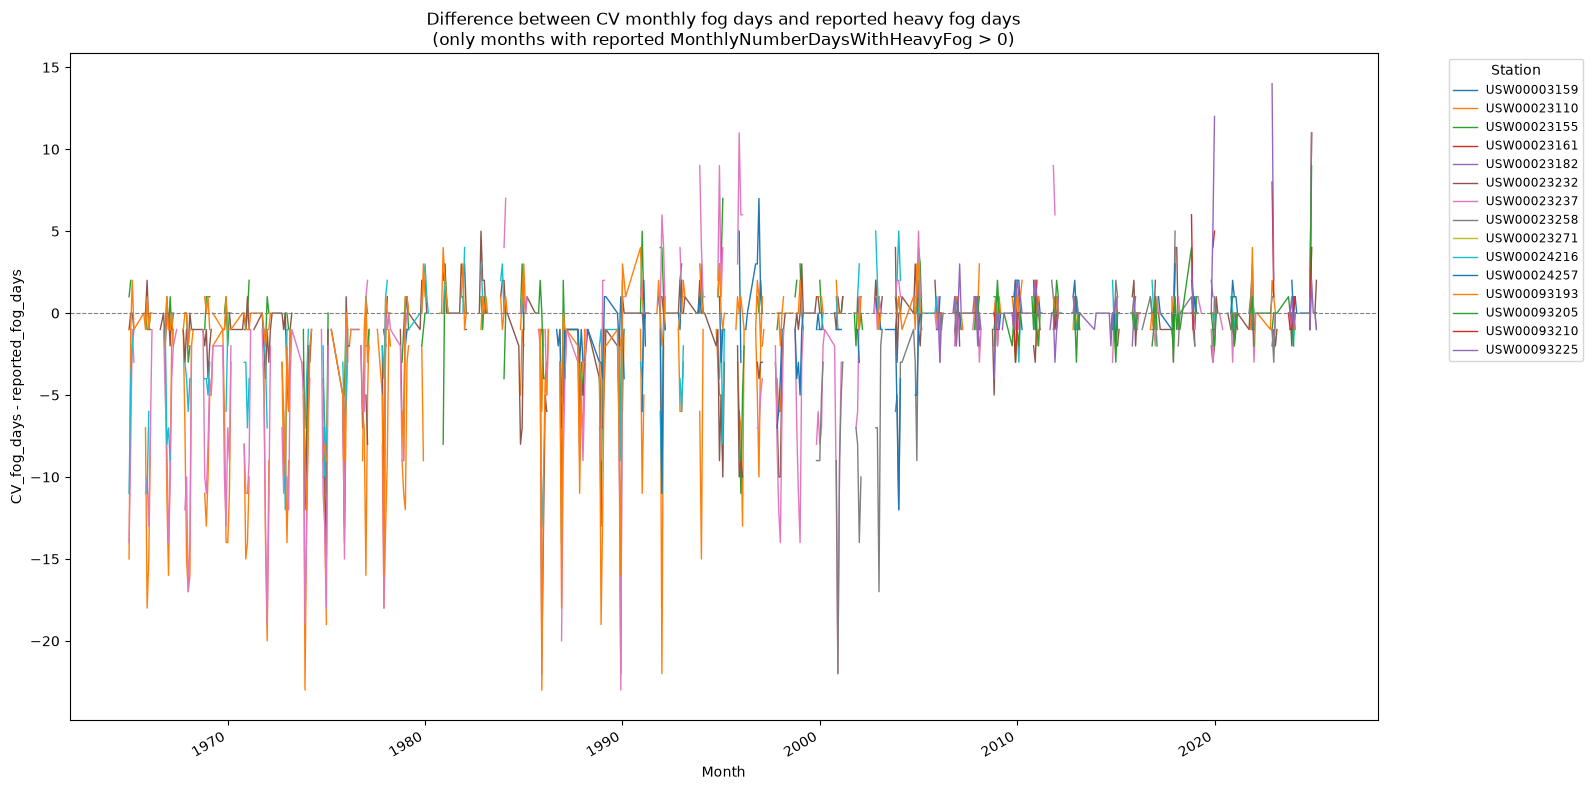

Total months with reported heavy fog > 0: 2096
Mismatches: 1420
        STATION  year  month  CV_fog_days  reported_fog_days  difference  \
43  USW00003159  1974     10          0.0                1.0        -1.0   
44  USW00003159  1976      2          0.0                1.0        -1.0   
45  USW00003159  1977      1          0.0                3.0        -3.0   
46  USW00003159  1977      3          0.0                1.0        -1.0   
47  USW00003159  1977     12          0.0                1.0        -1.0   
48  USW00003159  1978      1          0.0                2.0        -2.0   
49  USW00003159  1978     11          0.0                2.0        -2.0   
50  USW00003159  1979      1          0.0                2.0        -2.0   
51  USW00003159  1979      2          0.0                1.0        -1.0   
52  USW00003159  1981      1          0.0                3.0        -3.0   
53  USW00003159  1981      3          0.0                1.0        -1.0   
54  USW00003159  1982   

In [94]:
comparison_nonzero = comparison[comparison["reported_fog_days"] > 0].copy()

comparison_nonzero["period"] = pd.to_datetime(
    comparison_nonzero["year"].astype(str) + "-" +
    comparison_nonzero["month"].astype(str).str.zfill(2) + "-01"
)

diff_nonzero_pivot = comparison_nonzero.pivot_table(
    index="period",
    columns="STATION",
    values="difference"
)

fig, ax = plt.subplots(figsize=(16, 8))
diff_nonzero_pivot.plot(ax=ax, linewidth=1)
ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax.set_title("Difference between CV monthly fog days and reported heavy fog days\n(only months with reported MonthlyNumberDaysWithHeavyFog > 0)")
ax.set_xlabel("Month")
ax.set_ylabel("CV_fog_days - reported_fog_days")
ax.legend(title="Station", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize="small", ncol=1)
plt.tight_layout()
plt.show()

print("Total months with reported heavy fog > 0:", len(comparison_nonzero))
print("Mismatches:", len(comparison_nonzero[comparison_nonzero["difference"] != 0]))
print(comparison_nonzero[comparison_nonzero["difference"] != 0].head(20))

In [20]:
#get unique station names
unique_names = CV_fog_rows['STATION'].unique()
names_df = pd.DataFrame(unique_names)
print(unique_names)
print(names_df)

<StringArray>
['USW00093210', 'USW00024216', 'USW00093203', 'USW00024257', 'USW00023131',
 'USW00023206', 'USW00023182', 'USW00023208', 'USW00023258', 'USW00000479',
 'USW00093144', 'USW00023237', 'USW00093225', 'USW00023232', 'USW00093205',
 'USW00023161', 'USW00093193', 'USW00003159', 'USW00023203', 'USW00023114',
 'USW00023202', 'USW00023155', 'USW00023110', 'USW00093216', 'USW00023167']
Length: 25, dtype: str
              0
0   USW00093210
1   USW00024216
2   USW00093203
3   USW00024257
4   USW00023131
5   USW00023206
6   USW00023182
7   USW00023208
8   USW00023258
9   USW00000479
10  USW00093144
11  USW00023237
12  USW00093225
13  USW00023232
14  USW00093205
15  USW00023161
16  USW00093193
17  USW00003159
18  USW00023203
19  USW00023114
20  USW00023202
21  USW00023155
22  USW00023110
23  USW00093216
24  USW00023167


In [90]:
#count how many foggy hours per year for each station
foghrs_per_station = CV_fog_rows.groupby(['STATION', 'year']).size()
print(foghrs_per_station)

STATION      year
USW00000479  2014     18
             2015     23
             2016     49
             2017     36
             2018     19
                    ... 
USW00093225  2021    236
             2022    178
             2023     64
             2024     97
             2025     30
Length: 601, dtype: int64


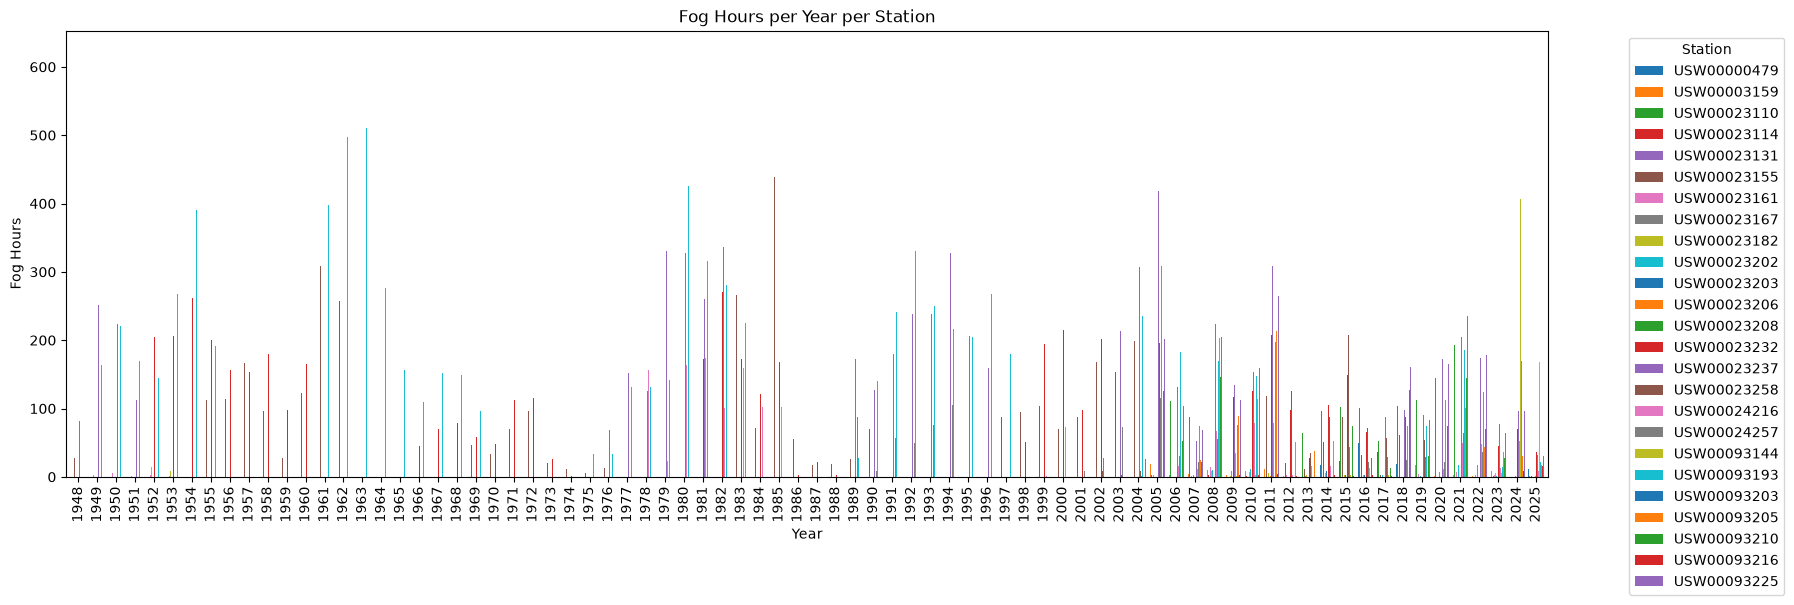

In [91]:
foghrs_per_station_unstack = foghrs_per_station.unstack('STATION').fillna(0)

foghrs_per_station_unstack.plot(
    kind='bar',
    figsize=(18, 6),
    width=0.8
)

plt.title('Fog Hours per Year per Station')
plt.xlabel('Year')
plt.ylabel('Fog Hours')
plt.legend(title='Station', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [92]:
fog_days_per_year = (
    CV_fog_rows
    .assign(fog_date=CV_fog_rows["DATE"].dt.date)
    .drop_duplicates(subset=["STATION", "year", "fog_date"])
    .groupby(["STATION", "year"])
    .size()
)

#for station in unique_names:
#    station_counts = fog_days_per_year.loc[station]
#    station_counts.plot(kind="bar", figsize=(10, 4))
#    plt.title(f"{station} Fog Days per Year")
#    plt.xlabel("Year")
#    plt.ylabel("Fog Days")
#    plt.tight_layout()
#    plt.show()

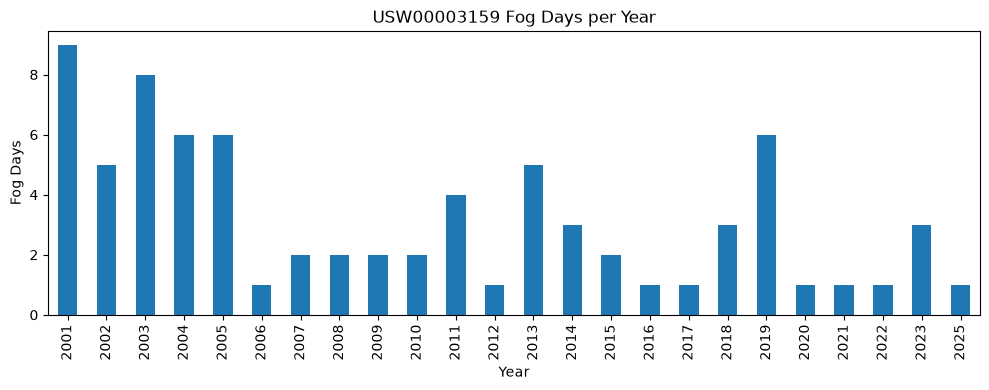

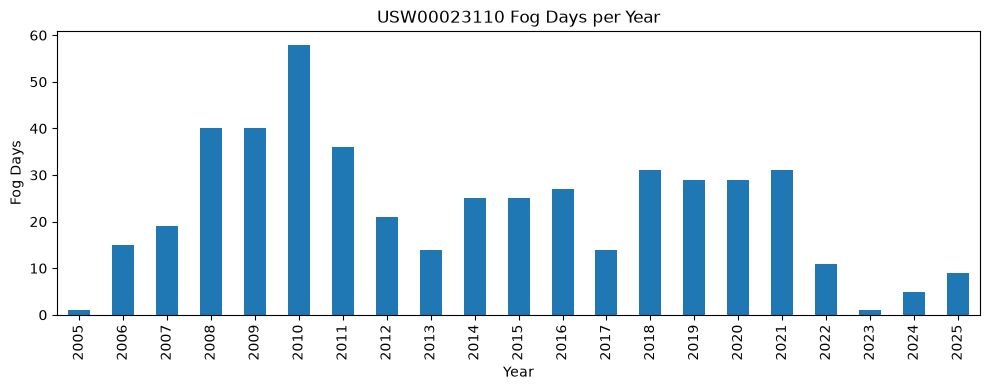

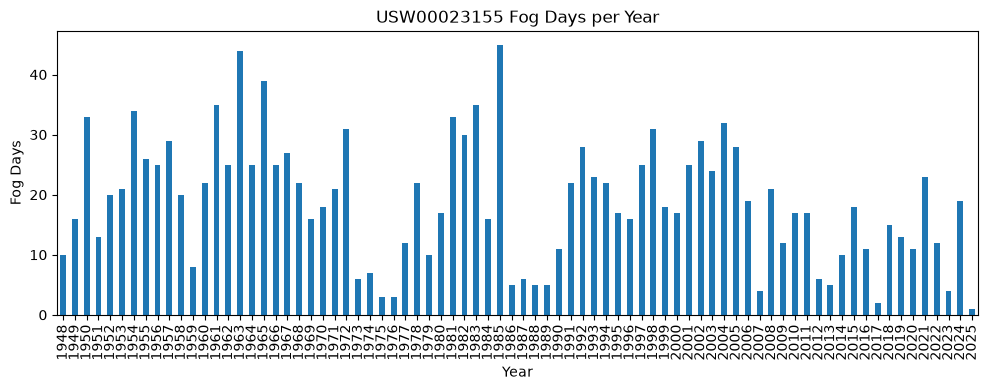

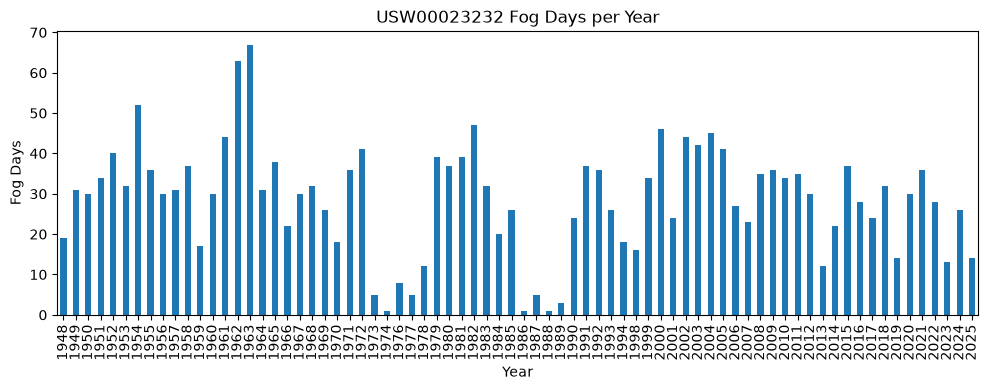

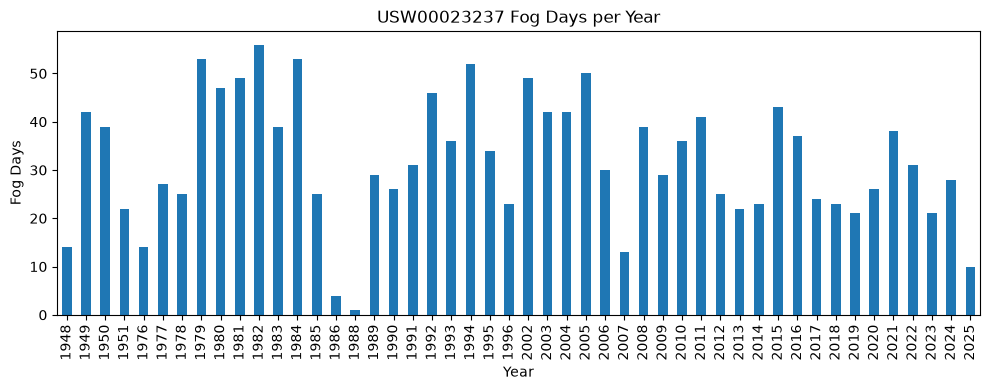

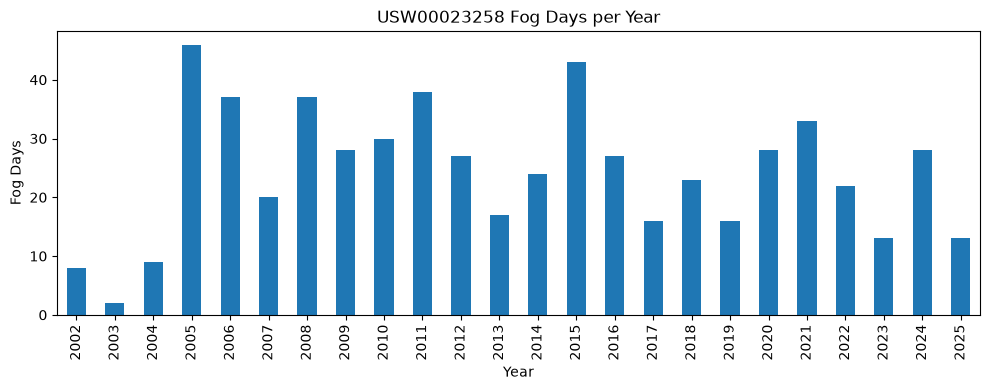

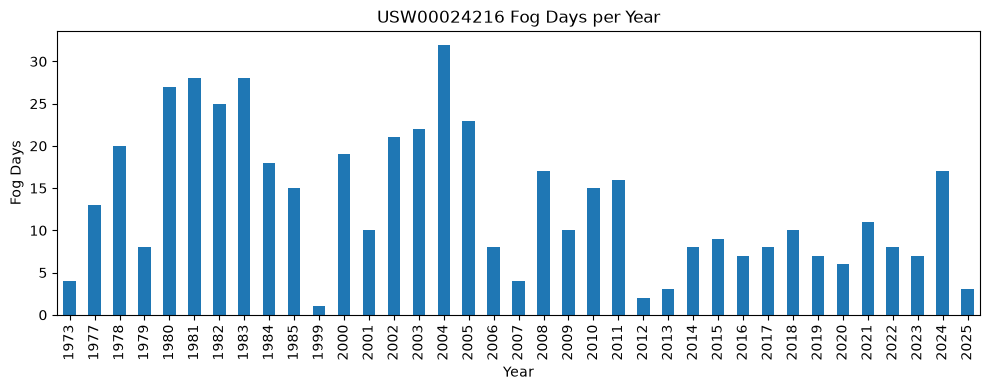

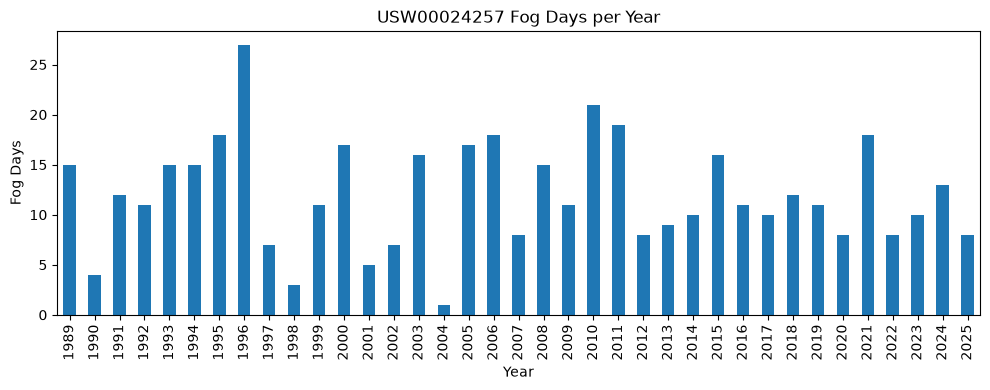

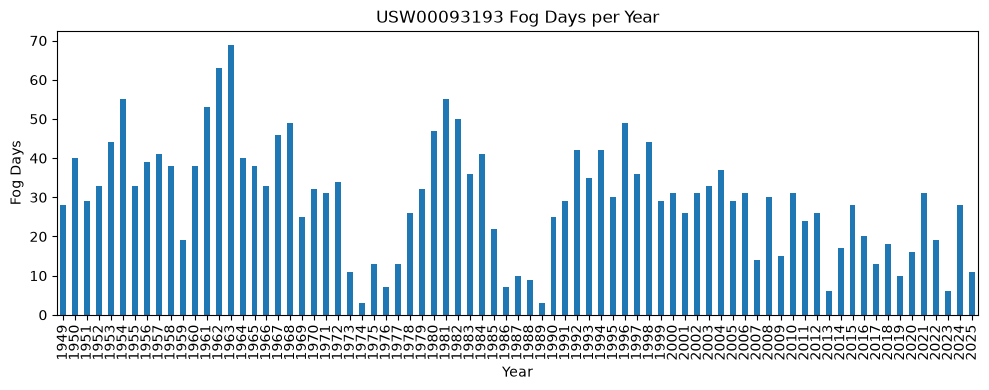

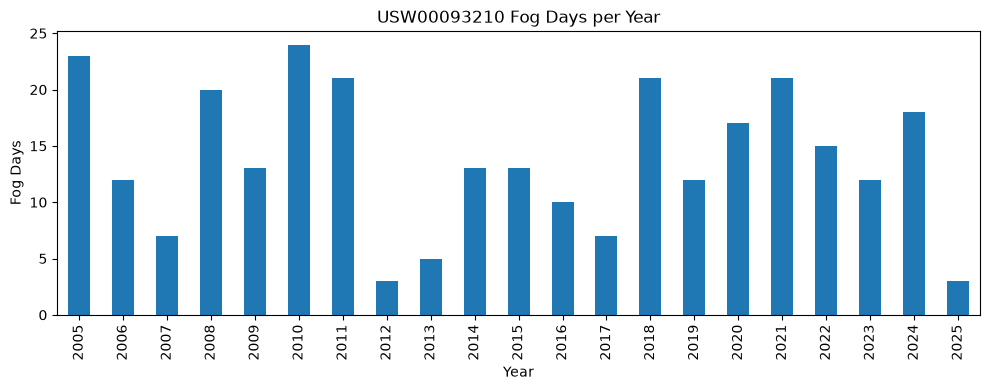

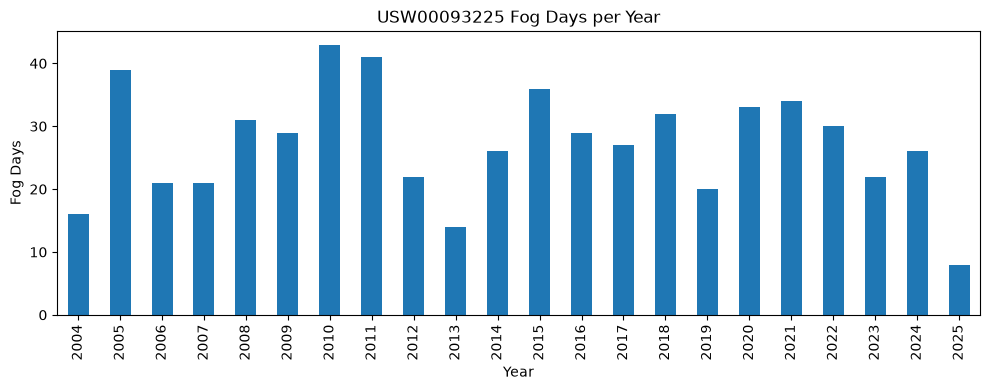

In [93]:
station_year_counts = fog_days_per_year.groupby(level='STATION').size()
stations_with_long_record = station_year_counts[station_year_counts > 20].index

for station in stations_with_long_record:
    station_counts = fog_days_per_year.loc[station]
    station_counts.plot(kind='bar', figsize=(10, 4))
    plt.title(f"{station} Fog Days per Year")
    plt.xlabel("Year")
    plt.ylabel("Fog Days")
    plt.tight_layout()
    plt.show()

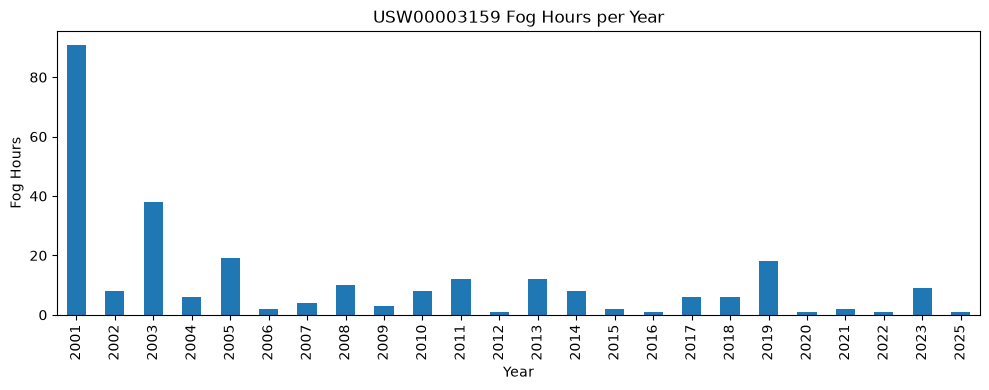

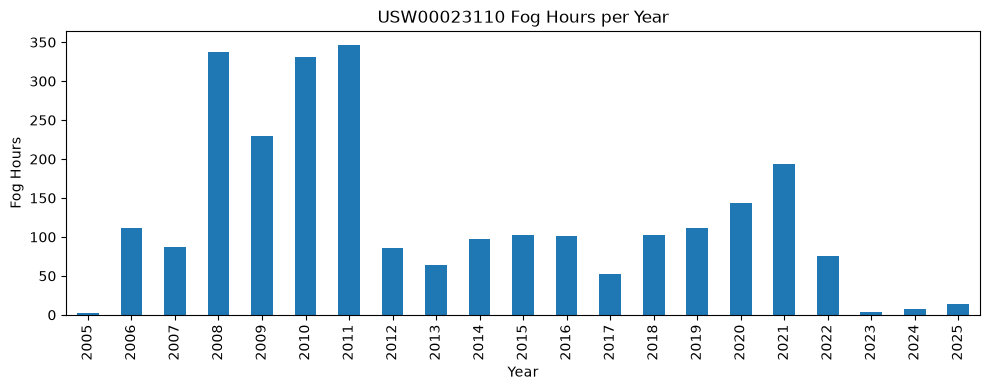

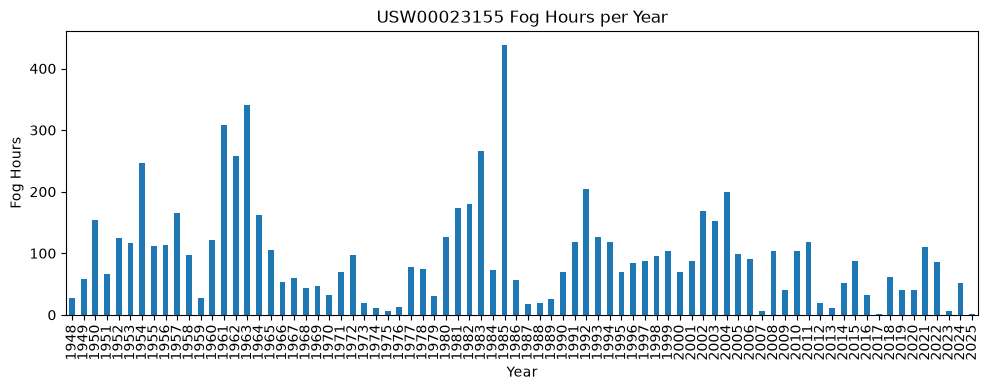

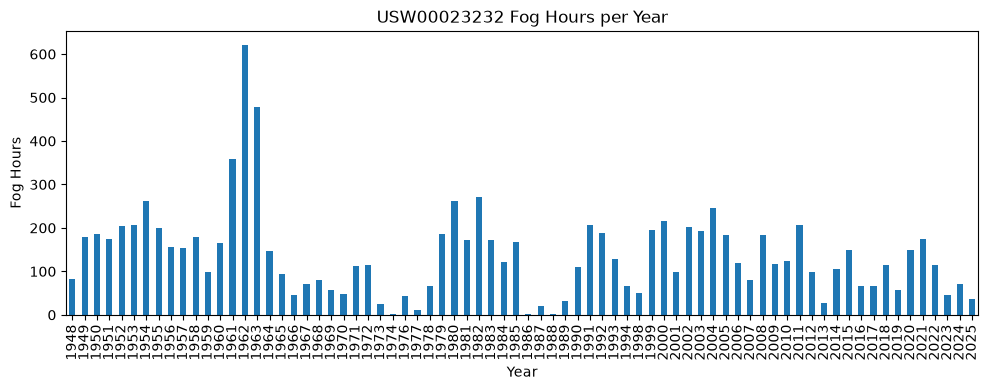

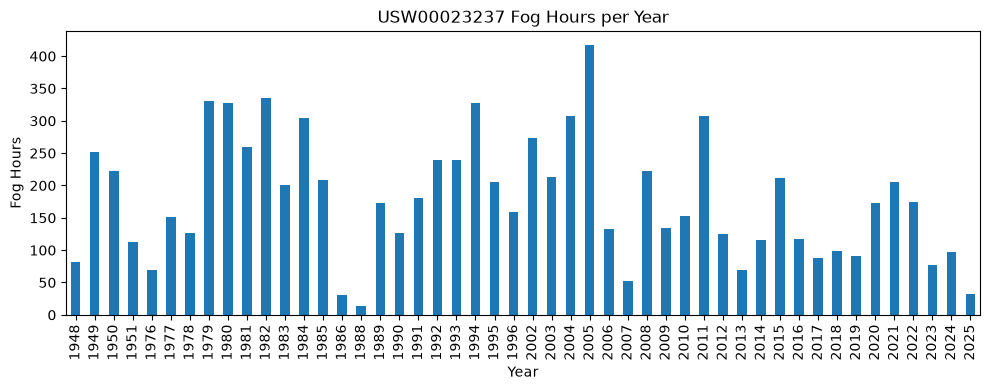

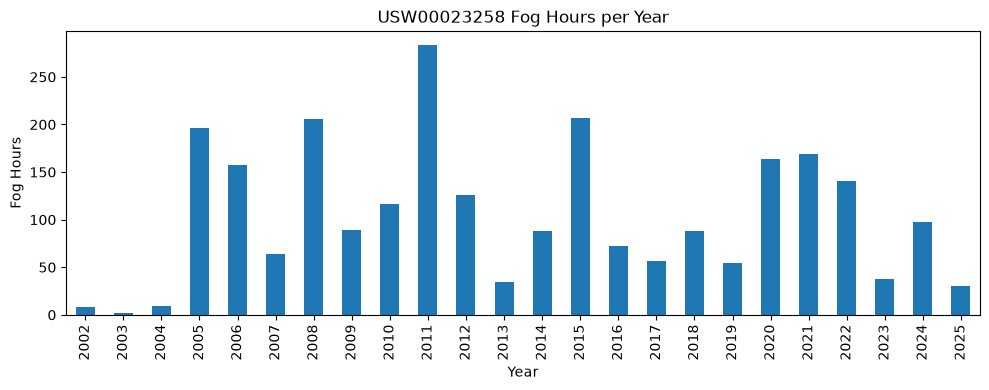

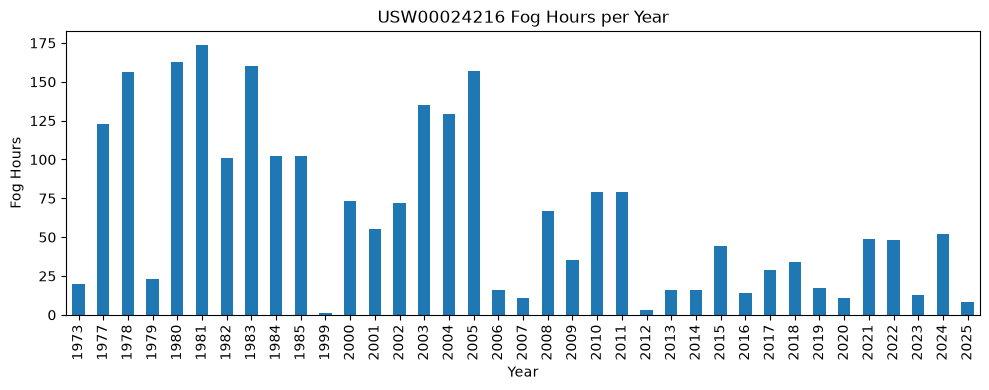

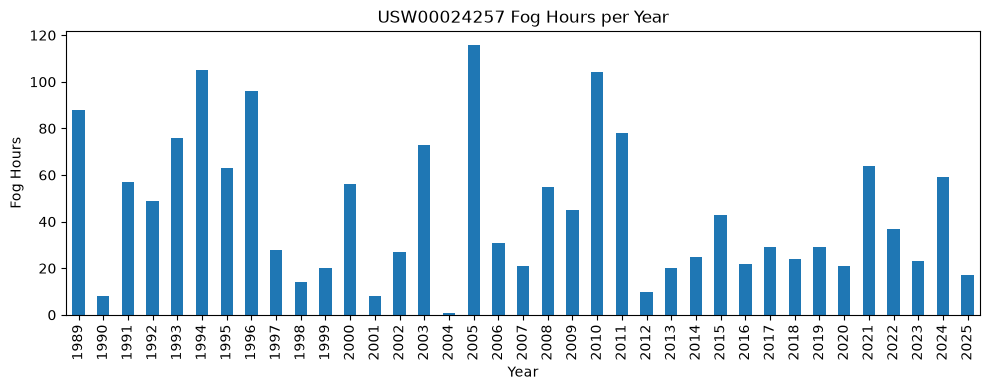

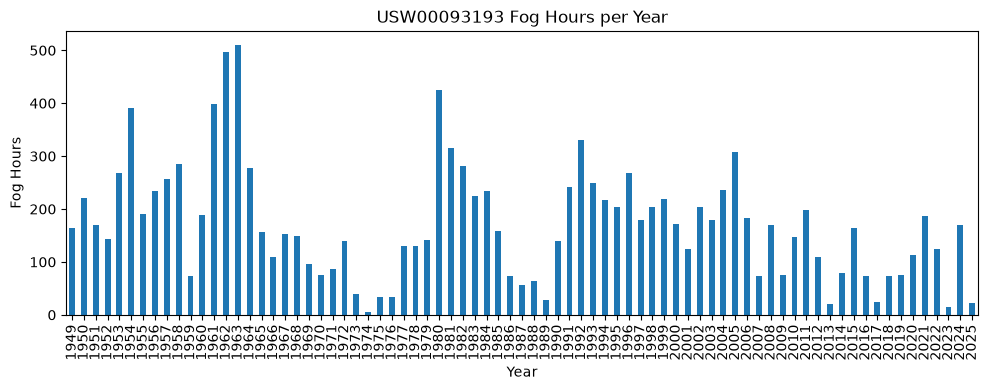

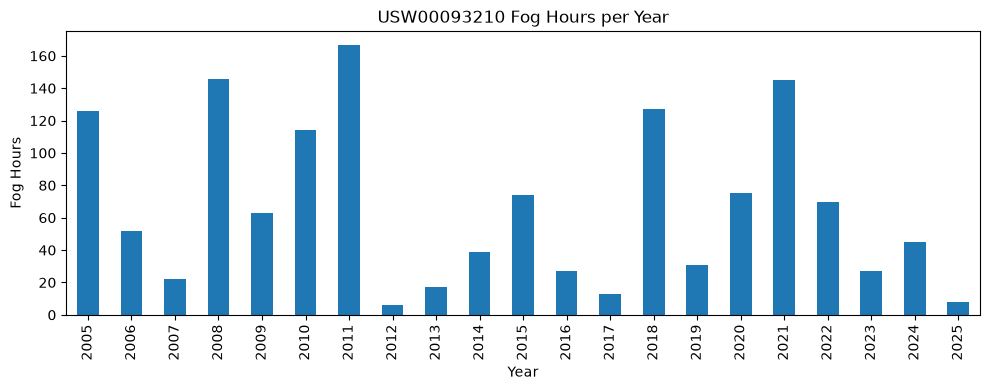

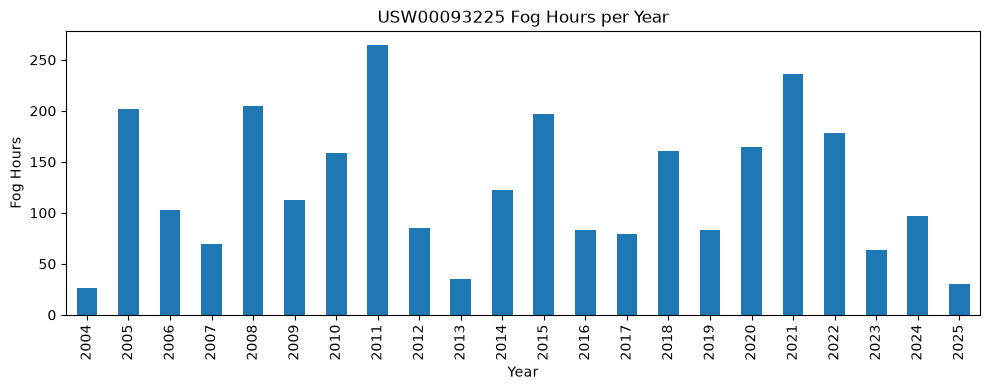

In [54]:
for station in stations_with_long_record:
    station_hours = foghrs_per_station.loc[station].sort_index()
    fig, ax = plt.subplots(figsize=(10, 4))
    station_hours.plot(kind='bar', ax=ax)
    ax.set_title(f"{station} Fog Hours per Year")
    ax.set_xlabel("Year")
    ax.set_ylabel("Fog Hours")
    plt.tight_layout()
    plt.show()

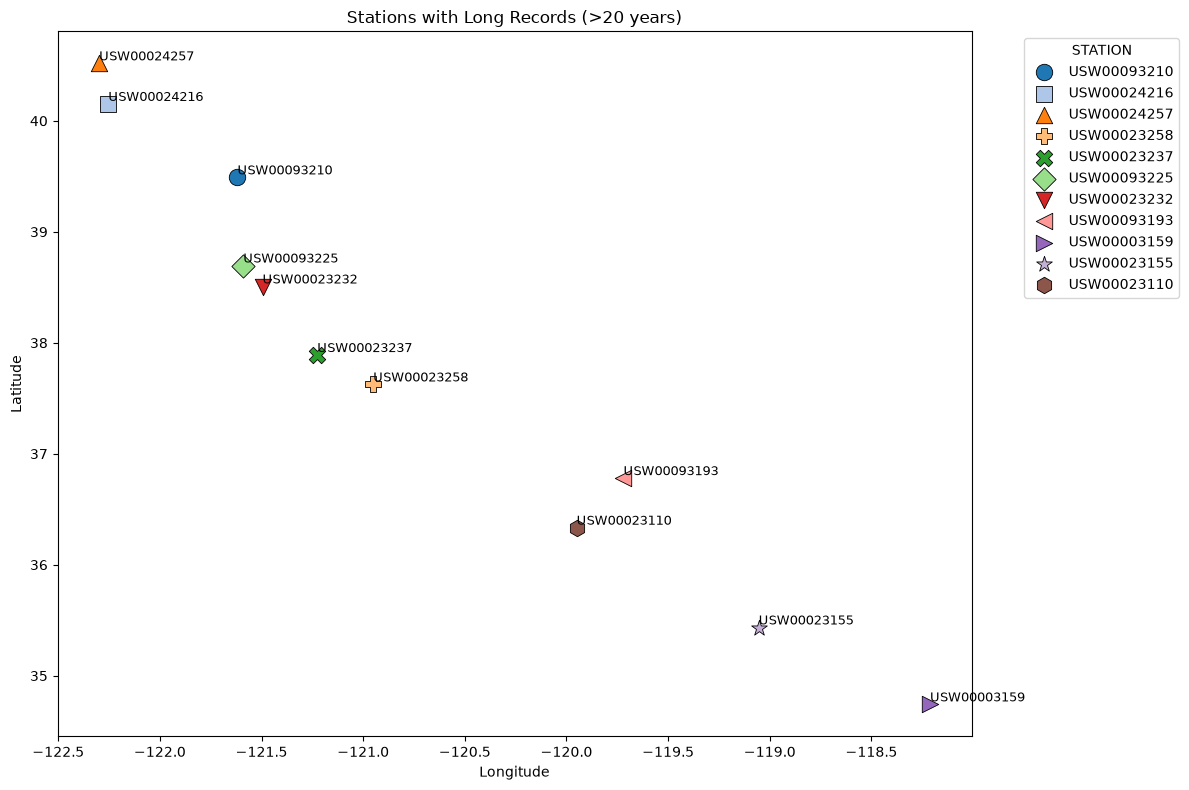

In [55]:
# create dataframe of unique station locations for stations_with_long_record
stations_long_locs = (
    CV_rows[CV_rows['STATION'].isin(stations_with_long_record)]
    .drop_duplicates(subset='STATION')
    .loc[:, ['STATION', 'LATITUDE', 'LONGITUDE']]
    .reset_index(drop=True)
)

# create GeoDataFrame
gdf_long = gpd.GeoDataFrame(
    stations_long_locs,
    geometry=gpd.points_from_xy(stations_long_locs['LONGITUDE'], stations_long_locs['LATITUDE']),
    crs="EPSG:4326"
)

# plot each station with a distinct marker and color
fig, ax = plt.subplots(figsize=(12, 8))
markers = ['o', 's', '^', 'P', 'X', 'D', 'v', '<', '>', '*', 'h']
cmap = plt.get_cmap('tab20')

for i, row in gdf_long.iterrows():
    ax.scatter(row.geometry.x, row.geometry.y,
               marker=markers[i % len(markers)],
               color=cmap(i % cmap.N),
               s=140, edgecolor='k', linewidth=0.6,
               label=row['STATION'])

# annotate points
for x, y, s in zip(gdf_long.geometry.x, gdf_long.geometry.y, gdf_long['STATION']):
    ax.text(x, y, s, fontsize=9, ha='left', va='bottom')

ax.set_title("Stations with Long Records (>20 years)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend(title='STATION', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [56]:
from scipy import stats

# Create a dataframe to store R-squared values for each station
r_squared_results = []

for station in stations_with_long_record:
    station_data = fog_days_per_year.loc[station].reset_index()
    station_data.columns = ['year', 'fog_days']
    
    # Perform linear regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(station_data['year'], station_data['fog_days'])
    r_squared = r_value ** 2
    
    r_squared_results.append({
        'STATION': station,
        'R_squared': r_squared,
        'p_value': p_value,
        'slope': slope,
        'intercept': intercept
    })

# Create results dataframe
regression_results = pd.DataFrame(r_squared_results)
regression_results = regression_results.sort_values('R_squared', ascending=False)

print(regression_results)
print("\nSummary Statistics:")
print(f"Mean R-squared: {regression_results['R_squared'].mean():.4f}")
print(f"Max R-squared: {regression_results['R_squared'].max():.4f}")
print(f"Min R-squared: {regression_results['R_squared'].min():.4f}")
print(f"Significant trends (p < 0.05): {len(regression_results[regression_results['p_value'] < 0.05])}")

        STATION     R_squared   p_value     slope    intercept
0   USW00003159  3.413965e-01  0.002716 -0.196912   399.460586
6   USW00024216  2.044571e-01  0.004959 -0.236964   487.978579
8   USW00093193  1.937765e-01  0.000062 -0.282744   591.382907
2   USW00023155  1.073281e-01  0.003412 -0.148042   312.969714
1   USW00023110  9.713745e-02  0.169028 -0.716883  1467.424242
10  USW00093225  2.353345e-02  0.495499 -0.208922   448.145116
3   USW00023232  2.219985e-02  0.205163 -0.087404   202.215652
9   USW00093210  1.834186e-02  0.558324 -0.141558   299.049784
4   USW00023237  9.828861e-03  0.502593 -0.063597   158.858624
7   USW00024257  6.430572e-03  0.637069 -0.040066    92.440256
5   USW00023258  7.335318e-08  0.998998 -0.000435    25.250435

Summary Statistics:
Mean R-squared: 0.0931
Max R-squared: 0.3414
Min R-squared: 0.0000
Significant trends (p < 0.05): 4


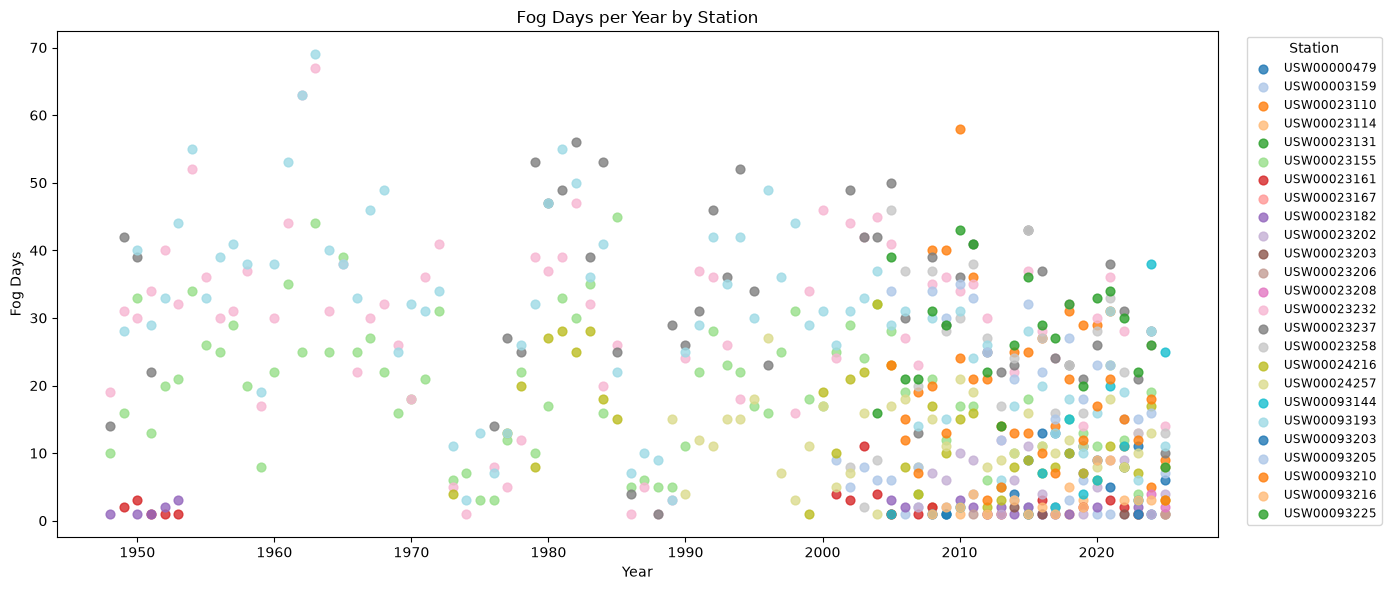

In [59]:
# scatter plot: fog days per year for each station (colored by station)
df_plot = fog_days_per_year.reset_index()
df_plot.columns = ['STATION', 'year', 'fog_days']

plt.figure(figsize=(14, 6))
cmap = plt.get_cmap("tab20")
stations_all = df_plot['STATION'].unique()
colors = {s: cmap(i % cmap.N) for i, s in enumerate(stations_all)}

for s in stations_all:
    sub = df_plot[df_plot['STATION'] == s]
    plt.scatter(sub['year'], sub['fog_days'], label=s, color=colors[s], s=40, alpha=0.8)

plt.xlabel("Year")
plt.ylabel("Fog Days")
plt.title("Fog Days per Year by Station")
plt.legend(title="Station", bbox_to_anchor=(1.02, 1), loc="upper left", ncol=1, fontsize='small')
plt.tight_layout()
plt.show()

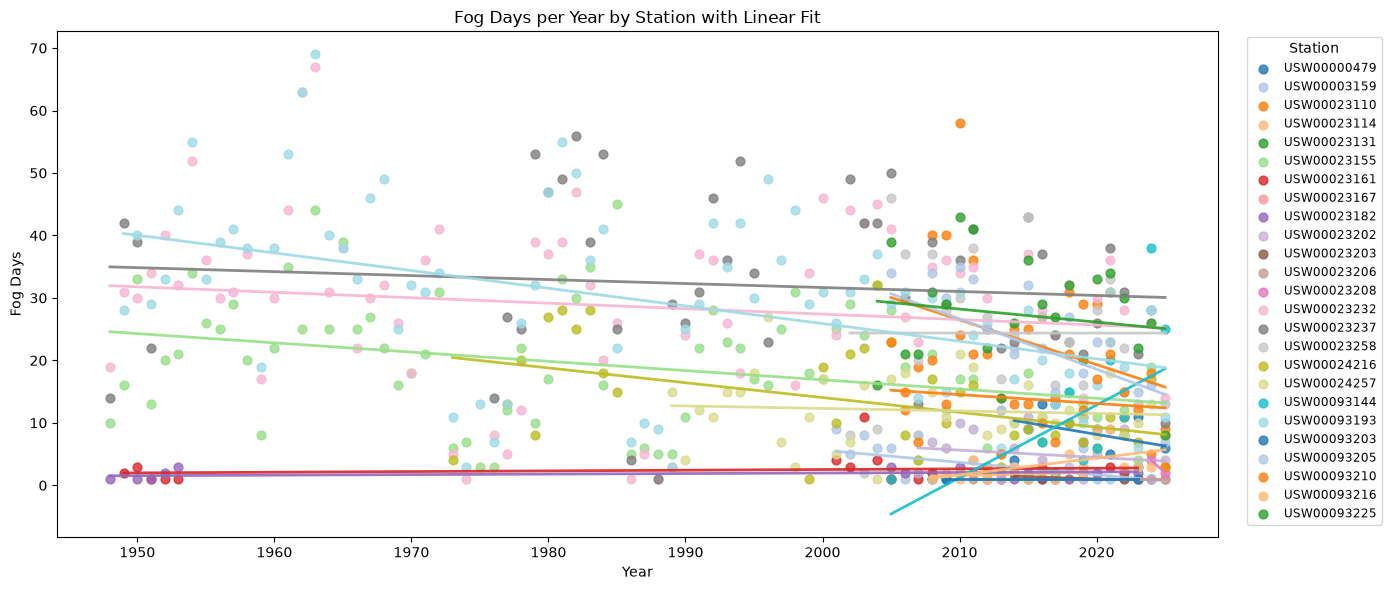

In [60]:
plt.figure(figsize=(14, 6))
for s in stations_all:
    sub = df_plot[df_plot['STATION'] == s]
    if sub.empty:
        continue
    c = colors.get(s, 'k')
    plt.scatter(sub['year'], sub['fog_days'], label=s, color=c, s=40, alpha=0.8)
    if sub['year'].nunique() > 1:
        slope, intercept, r_value, p_value, std_err = stats.linregress(sub['year'], sub['fog_days'])
        xvals = np.linspace(sub['year'].min(), sub['year'].max(), 100)
        yvals = intercept + slope * xvals
        plt.plot(xvals, yvals, color=c, linewidth=2, alpha=0.9)

plt.xlabel("Year")
plt.ylabel("Fog Days")
plt.title("Fog Days per Year by Station with Linear Fit")
plt.legend(title="Station", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize='small', ncol=1)
plt.tight_layout()
plt.show()

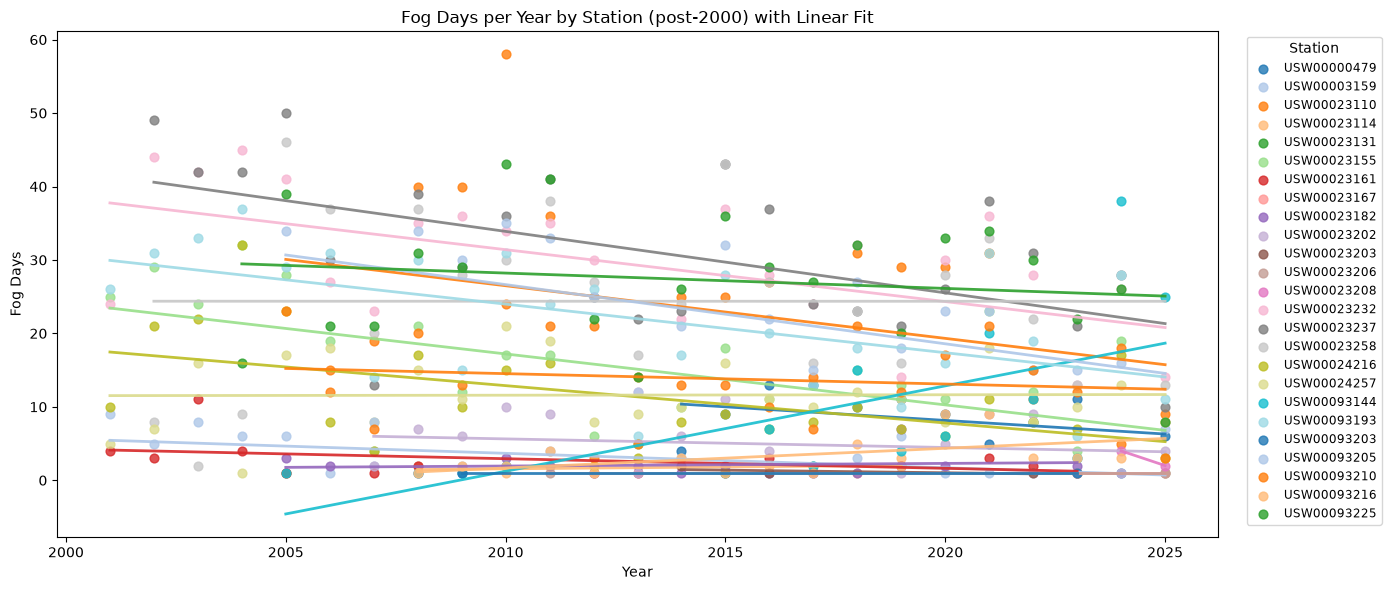

In [63]:
plt.figure(figsize=(14, 6))
for s in stations_all:
    sub = df_plot[(df_plot['STATION'] == s) & (df_plot['year'] > 2000)]
    if sub.empty:
        continue
    c = colors.get(s, 'k')
    plt.scatter(sub['year'], sub['fog_days'], label=s, color=c, s=40, alpha=0.8)
    if sub['year'].nunique() > 1:
        slope, intercept, r_value, p_value, std_err = stats.linregress(sub['year'], sub['fog_days'])
        xvals = np.linspace(sub['year'].min(), sub['year'].max(), 100)
        yvals = intercept + slope * xvals
        plt.plot(xvals, yvals, color=c, linewidth=2, alpha=0.9)

plt.xlabel("Year")
plt.ylabel("Fog Days")
plt.title("Fog Days per Year by Station (post-2000) with Linear Fit")
plt.legend(title="Station", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize='small', ncol=1)
plt.tight_layout()
plt.show()

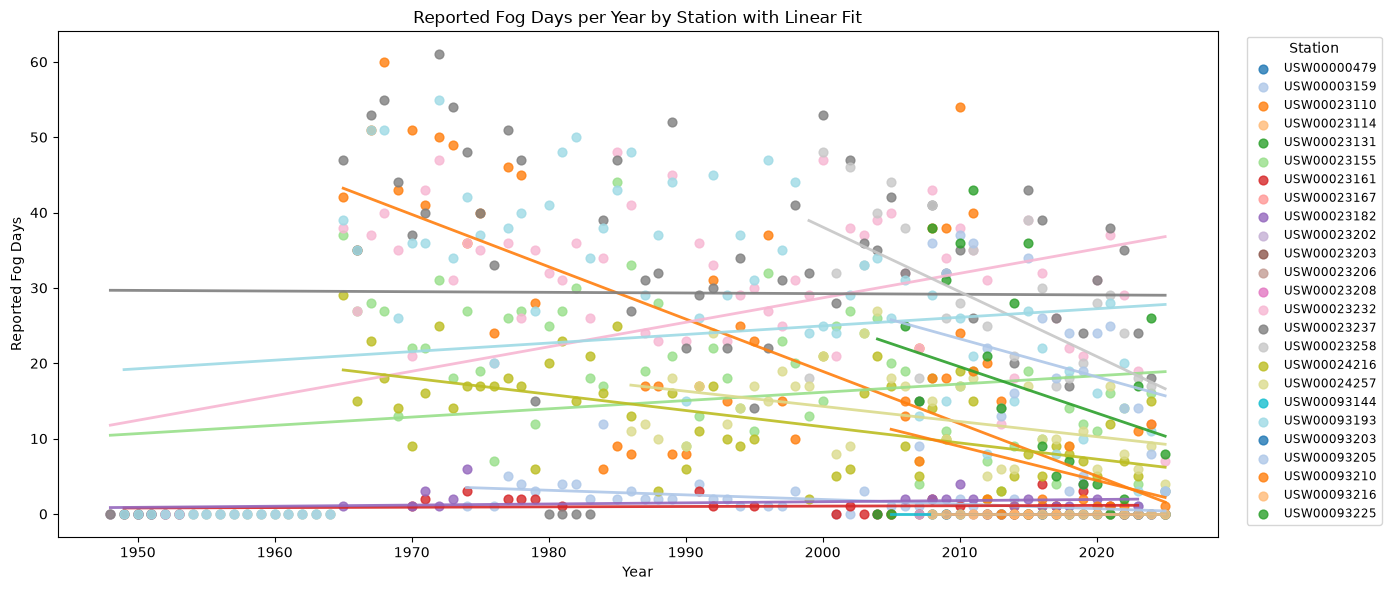

In [62]:
# Prepare data with reported fog days
df_reported = comparison.groupby(['STATION', 'year'])['reported_fog_days'].sum().reset_index()
df_reported.columns = ['STATION', 'year', 'reported_fog_days']

plt.figure(figsize=(14, 6))
for s in stations_all:
    sub = df_reported[df_reported['STATION'] == s]
    if sub.empty:
        continue
    c = colors.get(s, 'k')
    plt.scatter(sub['year'], sub['reported_fog_days'], label=s, color=c, s=40, alpha=0.8)
    if sub['year'].nunique() > 1:
        slope, intercept, r_value, p_value, std_err = stats.linregress(sub['year'], sub['reported_fog_days'])
        xvals = np.linspace(sub['year'].min(), sub['year'].max(), 100)
        yvals = intercept + slope * xvals
        plt.plot(xvals, yvals, color=c, linewidth=2, alpha=0.9)

plt.xlabel("Year")
plt.ylabel("Reported Fog Days")
plt.title("Reported Fog Days per Year by Station with Linear Fit")
plt.legend(title="Station", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize='small', ncol=1)
plt.tight_layout()
plt.show()

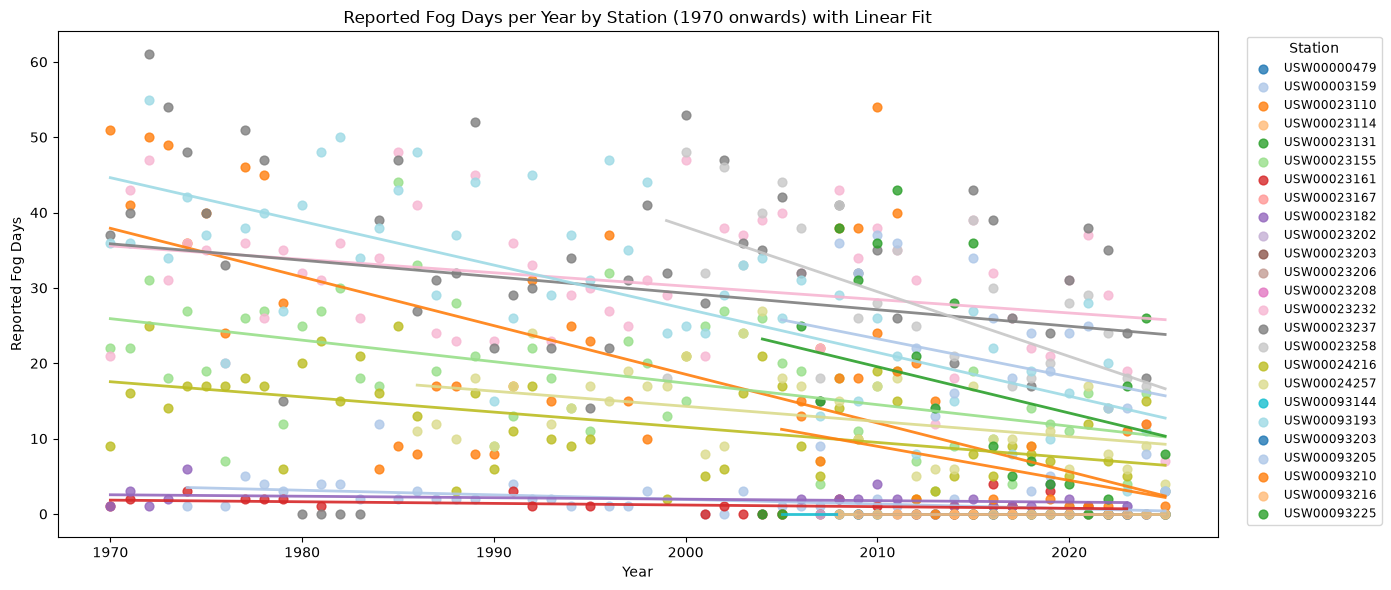

In [64]:
df_reported_1970 = df_reported[df_reported["year"] >= 1970]

plt.figure(figsize=(14, 6))
for s in stations_all:
    sub = df_reported_1970[df_reported_1970["STATION"] == s]
    if sub.empty:
        continue
    c = colors.get(s, "k")
    plt.scatter(sub["year"], sub["reported_fog_days"], label=s, color=c, s=40, alpha=0.8)
    if sub["year"].nunique() > 1:
        slope, intercept, r_value, p_value, std_err = stats.linregress(sub["year"], sub["reported_fog_days"])
        xvals = np.linspace(sub["year"].min(), sub["year"].max(), 100)
        yvals = intercept + slope * xvals
        plt.plot(xvals, yvals, color=c, linewidth=2, alpha=0.9)

plt.xlabel("Year")
plt.ylabel("Reported Fog Days")
plt.title("Reported Fog Days per Year by Station (1970 onwards) with Linear Fit")
plt.legend(title="Station", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize="small", ncol=1)
plt.tight_layout()
plt.show()